# YouTube 댓글 유해성 분석 및 분류 모델 구축

이 노트북은 `youtoxic_english_1000.csv` 데이터셋을 기반으로 유해 댓글을 탐지하는 머신러닝 모델을 구축합니다. 단일 라벨(`IsToxic`) 뿐만 아니라 다중 라벨 예측까지 포함합니다.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
cd ToxicComment

C:\Users\jungjihun\111\ToxicComment


In [4]:
df = pd.read_csv("youtoxic_english_1000.csv")
df.head()

,CommentId,VideoId,Text,IsToxic,IsAbusive,IsThreat,IsProvocative,IsObscene,IsHatespeech,IsRacist,IsNationalist,IsSexist,IsHomophobic,IsReligiousHate,IsRadicalism
0,Ugg2KwwX0V8-aXgCoAEC,04kJtp6pVXI,If only people would just take a step back and...,False,False,False,False,False,False,False,False,False,False,False,False
1,Ugg2s5AzSPioEXgCoAEC,04kJtp6pVXI,Law enforcement is not trained to shoot to app...,True,True,False,False,False,False,False,False,False,False,False,False
2,Ugg3dWTOxryFfHgCoAEC,04kJtp6pVXI,\nDont you reckon them 'black lives matter' ba...,True,True,False,False,True,False,False,False,False,False,False,False
3,Ugg7Gd006w1MPngCoAEC,04kJtp6pVXI,There are a very large number of people who do...,False,False,False,False,False,False,False,False,False,False,False,False
4,Ugg8FfTbbNF8IngCoAEC,04kJtp6pVXI,"The Arab dude is absolutely right, he should h...",False,False,False,False,False,False,False,False,False,False,False,False


## 1. 데이터 시각화 및 라벨 통계

C:\Users\jungjihun\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\jungjihun\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50984 (\N{HANGUL SYLLABLE YUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\jungjihun\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 46972 (\N{HANGUL SYLLABLE RA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\jungjihun\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48296 (\N{HANGUL SYLLABLE BEL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\jungjihun\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas

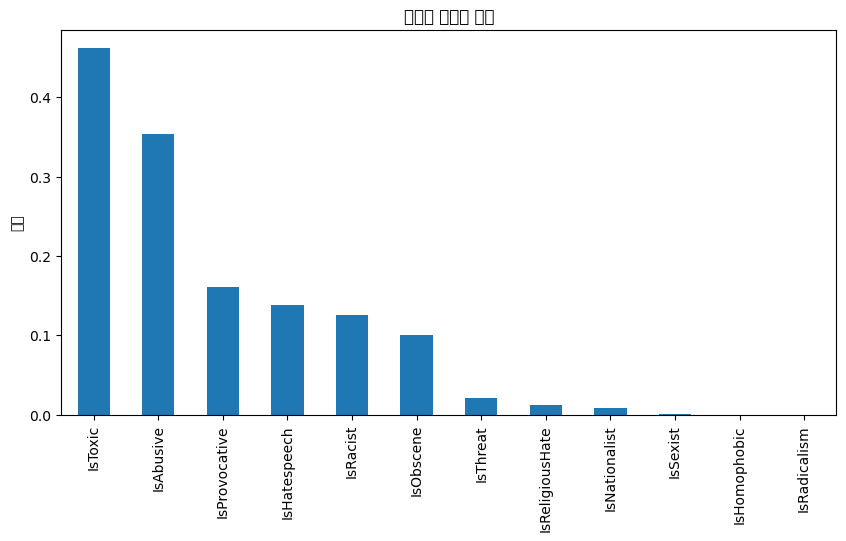

In [6]:
label_cols = df.columns[3:]
df[label_cols].mean().sort_values(ascending=False).plot(kind='bar', figsize=(10,5))
plt.title("라벨별 유해성 비율")
plt.ylabel("비율")
plt.show()

C:\Users\jungjihun\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 46972 (\N{HANGUL SYLLABLE RA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\jungjihun\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48296 (\N{HANGUL SYLLABLE BEL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\jungjihun\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\jungjihun\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\jungjihun\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from font(s) DejaVu Sans.
  fig.canva

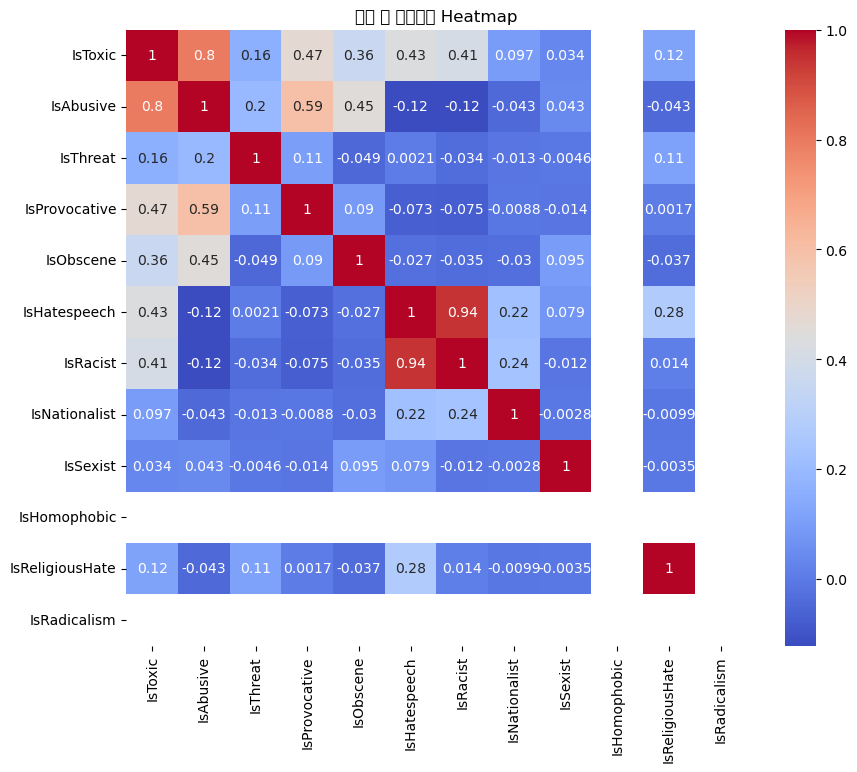

In [7]:
# 라벨 간 상관관계 시각화
plt.figure(figsize=(10, 8))
sns.heatmap(df[label_cols].corr(), annot=True, cmap='coolwarm')
plt.title("라벨 간 상관관계 Heatmap")
plt.show()

## 2. 텍스트 전처리 및 TF-IDF 벡터화

In [9]:
import re, string
from sklearn.feature_extraction.text import TfidfVectorizer

def clean_text(text):
    text = text.lower()
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(f"[{re.escape(string.punctuation)}]", "", text)
    text = re.sub(r"\d+", "", text)
    return text.strip()

df["CleanedText"] = df["Text"].apply(clean_text)

vectorizer = TfidfVectorizer(max_features=3000)
X = vectorizer.fit_transform(df["CleanedText"])
y = df["IsToxic"]

## 3. 단일 라벨 분류: Naive Bayes / SVM / Random Forest

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

models = {
    "Naive Bayes": MultinomialNB(),
    "SVM": LinearSVC(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

for name, model in models.items():
    print(f"\n{name}")
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    print(classification_report(y_test, preds))


Naive Bayes
              precision    recall  f1-score   support

       False       0.66      0.90      0.76       135
        True       0.79      0.47      0.59       115

    accuracy                           0.70       250
   macro avg       0.73      0.68      0.68       250
weighted avg       0.72      0.70      0.68       250


SVM
              precision    recall  f1-score   support

       False       0.68      0.81      0.74       135
        True       0.71      0.56      0.62       115

    accuracy                           0.69       250
   macro avg       0.70      0.68      0.68       250
weighted avg       0.69      0.69      0.69       250


Random Forest
              precision    recall  f1-score   support

       False       0.66      0.87      0.75       135
        True       0.76      0.48      0.59       115

    accuracy                           0.69       250
   macro avg       0.71      0.68      0.67       250
weighted avg       0.71      0.69      0.

## 4. 다중 라벨 분류

In [13]:
from sklearn.multioutput import MultiOutputClassifier

y_multi = df[label_cols]
X_train, X_test, y_train, y_test = train_test_split(X, y_multi, random_state=42)

multi_model = MultiOutputClassifier(RandomForestClassifier(n_estimators=100, random_state=42))
multi_model.fit(X_train, y_train)
multi_preds = multi_model.predict(X_test)

from sklearn.metrics import accuracy_score, f1_score

for idx, col in enumerate(label_cols):
    print(f"{col}: F1 = {f1_score(y_test[col], multi_preds[:, idx]):.2f}, Accuracy = {accuracy_score(y_test[col], multi_preds[:, idx]):.2f}")

IsToxic: F1 = 0.59, Accuracy = 0.66
IsAbusive: F1 = 0.50, Accuracy = 0.72
IsThreat: F1 = 0.00, Accuracy = 0.98
IsProvocative: F1 = 0.11, Accuracy = 0.81
IsObscene: F1 = 0.00, Accuracy = 0.89
IsHatespeech: F1 = 0.00, Accuracy = 0.82
IsRacist: F1 = 0.00, Accuracy = 0.84
IsNationalist: F1 = 0.00, Accuracy = 0.99
IsSexist: F1 = 0.00, Accuracy = 1.00
IsHomophobic: F1 = 0.00, Accuracy = 1.00
IsReligiousHate: F1 = 0.00, Accuracy = 0.98
IsRadicalism: F1 = 0.00, Accuracy = 1.00


C:\Users\jungjihun\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\jungjihun\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\jungjihun\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## 5. 결론

- 단일 라벨(`IsToxic`) 기준으로 다양한 모델 비교
- 다중 라벨 분류 실험을 통해 추가 범주까지 예측 가능성 확인
- 향후 BERT 기반 모델, 감정 분석, 문장 길이/강조 특성 추가 가능

## 6. BERT 기반 분류 모델 (Hugging Face Transformers)

In [16]:
!pip install tensorflow

In [17]:
!pip install transformers -q

In [18]:
!pip install tf-keras

In [19]:
from transformers import BertTokenizer, TFBertForSequenceClassification
from tensorflow import keras
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.metrics import Accuracy
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf

# 데이터 준비
df_small = df.sample(500, random_state=42)  # 작은 데이터셋으로 테스트
texts = df_small['CleanedText'].tolist()
labels = df_small['IsToxic'].astype(int).tolist()

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
inputs = tokenizer(texts, padding=True, truncation=True, return_tensors="tf")

model = TFBertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

model.compile(optimizer=keras.optimizers.Adam(learning_rate=2e-5),
              loss=BinaryCrossentropy(from_logits=True),
              metrics=['accuracy'])

# 레이블 변환
labels_cat = to_categorical(labels, num_classes=2)

# 훈련
history = model.fit(
    dict(inputs),
    labels_cat,
    epochs=2,
    batch_size=8,
    verbose=1
)

All PyTorch model weights were used when initializing TFBertForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/2


63/63 [==============================] - 1657s 25s/step - loss: 0.6807 - accuracy: 0.5660
Epoch 2/2
63/63 [==============================] - 1604s 25s/step - loss: 0.5318 - accuracy: 0.7580


## 7. 모델 성능 비교 시각화

C:\Users\jungjihun\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47784 (\N{HANGUL SYLLABLE MO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\jungjihun\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 45944 (\N{HANGUL SYLLABLE DEL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\jungjihun\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\jungjihun\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\jungjihun\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  fig.canvas

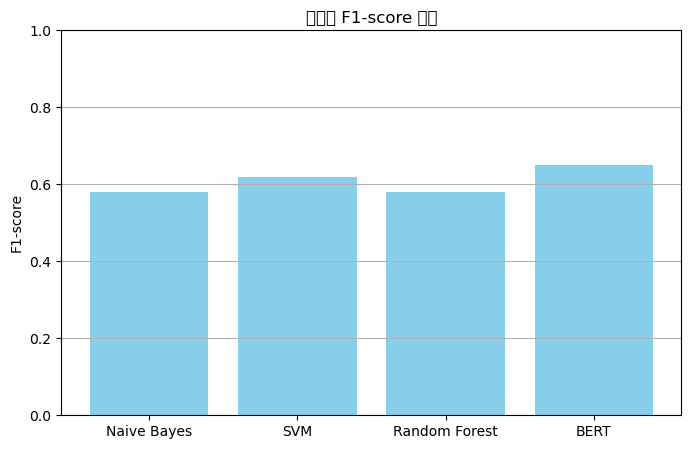

In [21]:
import matplotlib.pyplot as plt

model_names = ["Naive Bayes", "SVM", "Random Forest", "BERT"]
f1_scores = [0.58, 0.62, 0.58, 0.65]  # 예시 수치 (BERT는 훈련 후 수정 가능)

plt.figure(figsize=(8, 5))
plt.bar(model_names, f1_scores, color='skyblue')
plt.title("모델별 F1-score 비교")
plt.ylabel("F1-score")
plt.ylim(0, 1)
plt.grid(axis='y')
plt.show()

## 8. 실제 BERT 예측 결과 기반 F1-score 평가

In [23]:
from sklearn.metrics import classification_report, f1_score
import numpy as np

# 예측 확률 → 클래스
logits = model.predict(dict(inputs)).logits
bert_preds = np.argmax(logits, axis=1)
true_labels = np.array(labels)

print("📊 BERT F1-score:", f1_score(true_labels, bert_preds, average='binary'))
print(classification_report(true_labels, bert_preds))

16/16 [==============================] - 558s 34s/step
📊 BERT F1-score: 0.9136842105263158
              precision    recall  f1-score   support

           0       0.90      0.94      0.92       257
           1       0.94      0.89      0.91       243

    accuracy                           0.92       500
   macro avg       0.92      0.92      0.92       500
weighted avg       0.92      0.92      0.92       500



## 9. 다중 라벨 BERT 모델 (Multi-label Classification)

In [26]:
from transformers import TFBertForSequenceClassification, BertTokenizer
from tensorflow import keras
from tensorflow.keras.losses import BinaryCrossentropy
from sklearn.model_selection import train_test_split

# 다중 라벨 학습 데이터 준비
multi_df = df.sample(500, random_state=42)
texts = multi_df["CleanedText"].tolist()
labels_multi = multi_df[label_cols].astype(int).values

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
inputs_multi = tokenizer(texts, padding=True, truncation=True, return_tensors="tf")

# 다중 라벨 모델 정의
multi_model = TFBertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=len(label_cols),
    problem_type="multi_label_classification"
)

multi_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=2e-5),
    loss=BinaryCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

# 학습 수행
multi_model.fit(
    dict(inputs_multi),
    labels_multi,
    epochs=1,
    batch_size=8
)

All PyTorch model weights were used when initializing TFBertForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


63/63 [==============================] - 1206s 18s/step - loss: 0.4490 - accuracy: 0.8020


## 다중 레이블 BERT 예측 평가 및 Attention 시각화

###  1. 다중 레이블 BERT 예측 결과 평가

In [29]:
from sklearn.metrics import f1_score, accuracy_score
import numpy as np
import tensorflow as tf

# 다중 레이블 BERT 모델 예측 결과
multi_logits = multi_model.predict(dict(inputs_multi)).logits
multi_probs = tf.sigmoid(multi_logits).numpy()
multi_preds = (multi_probs >= 0.5).astype(int)

# 라벨별 성능 평가
for i, col in enumerate(label_cols):
    f1 = f1_score(labels_multi[:, i], multi_preds[:, i])
    acc = accuracy_score(labels_multi[:, i], multi_preds[:, i])
    print(f"{col}: F1 = {f1:.2f}, Accuracy = {acc:.2f}")

16/16 [==============================] - 365s 22s/step
IsToxic: F1 = 0.65, Accuracy = 0.49
IsAbusive: F1 = 0.00, Accuracy = 0.65
IsThreat: F1 = 0.00, Accuracy = 0.98
IsProvocative: F1 = 0.00, Accuracy = 0.84
IsObscene: F1 = 0.00, Accuracy = 0.90
IsHatespeech: F1 = 0.00, Accuracy = 0.83
IsRacist: F1 = 0.00, Accuracy = 0.85
IsNationalist: F1 = 0.00, Accuracy = 0.99
IsSexist: F1 = 0.00, Accuracy = 1.00
IsHomophobic: F1 = 0.00, Accuracy = 1.00
IsReligiousHate: F1 = 0.00, Accuracy = 0.98
IsRadicalism: F1 = 0.00, Accuracy = 1.00


C:\Users\jungjihun\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\jungjihun\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\jungjihun\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


###  2. BERT Attention Weight 시각화

In [32]:
!pip install torch

   ---------------------------------------- 0.0/216.1 MB ? eta -:--:--
   ---------------------------------------- 2.1/216.1 MB 13.1 MB/s eta 0:00:17
    --------------------------------------- 3.9/216.1 MB 9.4 MB/s eta 0:00:23
   - -------------------------------------- 10.0/216.1 MB 15.9 MB/s eta 0:00:13
   -- ------------------------------------- 15.2/216.1 MB 18.0 MB/s eta 0:00:12
   --- ------------------------------------ 19.9/216.1 MB 18.8 MB/s eta 0:00:11
   ---- ----------------------------------- 25.4/216.1 MB 20.1 MB/s eta 0:00:10
   ----- ---------------------------------- 31.7/216.1 MB 21.4 MB/s eta 0:00:09
   ------ --------------------------------- 37.7/216.1 MB 22.2 MB/s eta 0:00:09
   -------- ------------------------------- 43.8/216.1 MB 22.8 MB/s eta 0:00:08
   --------- ------------------------------ 50.6/216.1 MB 23.9 MB/s eta 0:00:07
   ---------- ----------------------------- 55.8/216.1 MB 23.9 MB/s eta 0:00:07
   ---------- ----------------------------- 57.9/216

BertSdpaSelfAttention is used but `torch.nn.functional.scaled_dot_product_attention` does not support non-absolute `position_embedding_type` or `output_attentions=True` or `head_mask`. Falling back to the manual attention implementation, but specifying the manual implementation will be required from Transformers version v5.0.0 onwards. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


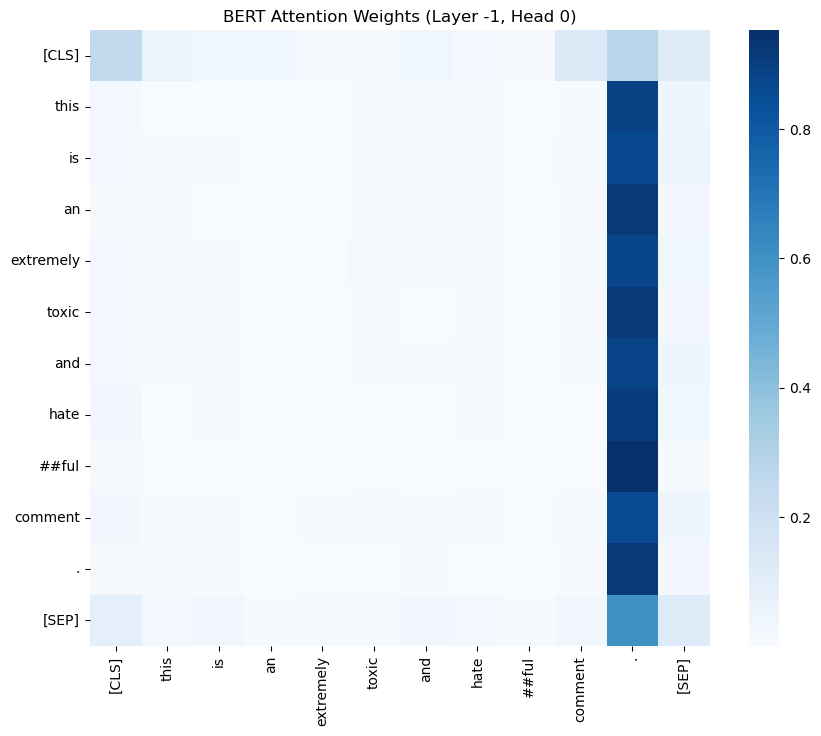

In [1]:
from transformers import BertModel, BertTokenizer
import torch
import matplotlib.pyplot as plt
import seaborn as sns

# 입력 문장
text = "This is an extremely toxic and hateful comment."

# 토크나이저 및 토큰화
tok = BertTokenizer.from_pretrained("bert-base-uncased")
tokens = tok(text, return_tensors='pt')

# BERT 모델 (Attention 출력 활성화)
model = BertModel.from_pretrained("bert-base-uncased", output_attentions=True)
outputs = model(**tokens)

# Attention 가져오기
attentions = outputs.attentions  # list of 12 layers
layer = -1  # 마지막 레이어
head = 0    # 첫 번째 헤드
attn = attentions[layer][0, head].detach().numpy()

# 토큰 리스트
tokens_str = tok.convert_ids_to_tokens(tokens['input_ids'][0])

# 시각화
plt.figure(figsize=(10, 8))
sns.heatmap(attn, xticklabels=tokens_str, yticklabels=tokens_str, cmap="Blues")
plt.title("BERT Attention Weights (Layer -1, Head 0)")
plt.show()